In [2]:
import numpy as np
import math
import os
from tqdm import tqdm
import torch
import random
import matplotlib.pyplot as plt

In [3]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [4]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


# PREPROCESSING

In [ ]:
from monai.transforms import (
    Compose, 
    LoadImaged,
    EnsureTyped, 
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,
    SpatialPadd,
    Resized,
    RandFlipd,
    RandCropByPosNegLabeld,
    RandRotate90d,
    ToTensord
)

from monai.data import (
    DataLoader,
    CacheDataset,
    Dataset,
    load_decathlon_datalist
)

# from torch.utils.data import DataLoader
from monai.utils import set_determinism

min_slices = 64
# pixdim=(1.5, 1.5, 2.0)
pixdim=(1.5, 1.5, 1.0)
a_min = -200 #-150, 250
a_max = 200
spatial_size = (128,128, min_slices)
set_determinism(seed=1)

train_transforms = Compose([
    LoadImaged(keys = ['vol', 'seg']),
    EnsureChannelFirstd(keys = ['vol', 'seg']),
    Spacingd(keys =['vol', 'seg'], pixdim = pixdim, mode=("bilinear", "nearest") ),
    Orientationd(keys =['vol', 'seg'], axcodes = "RAS"),
    ScaleIntensityRanged(keys=["vol"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys =['vol', 'seg'], source_key='vol'),

    # crop spatial_size, pos/neg = 1/1 ratio means half of the pixels of extracted patches will be around labels and half will be background
    RandCropByPosNegLabeld(
            keys=["vol", "seg"],
            label_key="seg",
            spatial_size=spatial_size,
            pos=1,
            neg=1,
            num_samples=4,
            image_key="vol",
            image_threshold=0,
            # allow_smaller=True,
        ),

    SpatialPadd(keys=['vol', 'seg'], spatial_size=spatial_size),
    #order
    RandFlipd(keys=["vol", "seg"], spatial_axis=[0], prob=0.10),
    RandFlipd(keys=["vol", "seg"], spatial_axis=[1], prob=0.10),
    RandFlipd(keys=["vol", "seg"], spatial_axis=[2], prob=0.10),
    RandRotate90d(keys=['vol', 'seg'], prob=0.1, max_k=3),

    # Resized(keys =['vol', 'seg'], spatial_size=spatial_size, mode=("trilinear", "nearest")),
    ToTensord(keys=["vol", "seg"]),
])

valid_transforms = Compose([
    LoadImaged(keys = ['vol', 'seg']),
    EnsureChannelFirstd(keys = ['vol', 'seg']),
    Spacingd(keys =['vol', 'seg'], pixdim = pixdim, mode=("bilinear", "nearest") ),
    Orientationd(keys =['vol', 'seg'], axcodes = "RAS"),
    ScaleIntensityRanged(keys=["vol"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys =['vol', 'seg'], source_key='vol'),
    # Resized(keys =['vol', 'seg'], spatial_size=spatial_size, mode=("trilinear", "nearest")),
    ToTensord(keys=["vol", "seg"]),
])

inference_transforms = Compose([
    LoadImaged(keys = ['vol', 'seg']),
    EnsureChannelFirstd(keys = ['vol', 'seg']),
    Spacingd(keys =['vol', 'seg'], pixdim = pixdim, mode=("bilinear", "nearest") ),
    Orientationd(keys =['vol', 'seg'], axcodes = "RAS"),
    ScaleIntensityRanged(keys=["vol"], a_min=a_min, a_max=a_max, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys =['vol', 'seg'], source_key='vol'),
    ToTensord(keys=["vol", "seg"]),
])

/Users/rojankarki/Projects/LearningML/cancer-imaging/.venv/lib/python3.14/site-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [6]:
data_dir = "./sample/"
split_json = "dataset.json"

datasets = data_dir + split_json
training_files = load_decathlon_datalist(datasets, True, "train")
val_files = load_decathlon_datalist(datasets, True, "valid")
train_ds = CacheDataset(
    data=training_files,
    transform=train_transforms,
    cache_rate=0.6,
    num_workers=6,
    )
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_ds = CacheDataset(data=val_files, transform=valid_transforms, cache_rate=1.0, num_workers=6)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

Loading dataset: 100%|██████████| 15/15 [00:35<00:00,  2.36s/it]


In [6]:
# check shape if they are uniform and label values
def verify_samples(dataloader, max_sample_size = 15):
    sample_size = min(len(dataloader), max_sample_size)
    random_indices = random.sample(range(len(dataloader)), sample_size)

    for i, batch in enumerate(dataloader):
        if i in random_indices:
            volume = batch['vol']
            label = batch['seg']
            print(f"Checking batch:{i} \t",volume.shape, label.shape, torch.unique(label))  

In [7]:
verify_samples(train_loader, 10)

Checking batch:4 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:7 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1.])
Checking batch:8 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:16 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:24 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:28 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1.])
Checking batch:30 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:31 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1.])
Checking batch:36 	 torch.Size([4, 1, 128, 128, 64]) torch.Size([4, 1, 128, 128, 64]) metatensor([0., 1., 2.])
Checking batch:4

In [8]:
verify_samples(val_loader, 10)

Checking batch:0 	 torch.Size([1, 1, 241, 208, 478]) torch.Size([1, 1, 241, 208, 478]) metatensor([0., 1., 2.])
Checking batch:1 	 torch.Size([1, 1, 245, 232, 474]) torch.Size([1, 1, 245, 232, 474]) metatensor([0., 1., 2.])
Checking batch:3 	 torch.Size([1, 1, 266, 200, 625]) torch.Size([1, 1, 266, 200, 625]) metatensor([0., 1., 2.])
Checking batch:5 	 torch.Size([1, 1, 247, 191, 617]) torch.Size([1, 1, 247, 191, 617]) metatensor([0., 1.])
Checking batch:6 	 torch.Size([1, 1, 267, 228, 617]) torch.Size([1, 1, 267, 228, 617]) metatensor([0., 1., 2.])
Checking batch:7 	 torch.Size([1, 1, 249, 214, 685]) torch.Size([1, 1, 249, 214, 685]) metatensor([0., 1., 2.])
Checking batch:9 	 torch.Size([1, 1, 246, 183, 653]) torch.Size([1, 1, 246, 183, 653]) metatensor([0., 1., 2.])
Checking batch:10 	 torch.Size([1, 1, 267, 238, 609]) torch.Size([1, 1, 267, 238, 609]) metatensor([0., 1., 2.])
Checking batch:12 	 torch.Size([1, 1, 267, 225, 669]) torch.Size([1, 1, 267, 225, 669]) metatensor([0., 1.,

# MODEL ARCHITECTURE

In [7]:
from monai.networks.nets import Unet
from monai.networks.layers import Norm
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch


base = 16
channels = tuple(base * int(math.pow(2, x)) for x in range(5))
strides = (2, 2, 2, 2)
model = Unet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=channels,
    strides=strides,
    num_res_units=2,
    norm=Norm.BATCH  #Norm.INSTANCE
).to(device)

In [8]:
from monai.losses import DiceCELoss, DiceLoss
loss_function = DiceCELoss(softmax=True, to_onehot_y= True, include_background=False, squared_pred=True)

from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete

dice_metric = DiceMetric(include_background=False, reduction="mean")
dice_metric_per_class = DiceMetric(include_background=False, reduction="mean_batch")
post_pred = AsDiscrete(argmax=True, to_onehot=3)
post_label = AsDiscrete(to_onehot=3)

In [9]:
import torch
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5, amsgrad=True)

# TRAINING

In [40]:
def train_one_epoch(model, train_loader, loss, optim, device):
    model.train()
    train_epoch_loss = 0
    dice_metric.reset()   
    train_steps = 0

    for batch in train_loader:

        train_steps += 1

        volume, label = batch['vol'].to(device), batch['seg'].to(device)
        # label = label != 0 # convert labels into bool mask, all values other than 0 is True

        # label[label > 0] = 1
        optim.zero_grad()

        output = model(volume)
        train_loss = loss(output, label)
        train_loss.backward()
        optim.step()

        train_epoch_loss += train_loss.item()

        output_list = decollate_batch(output)
        label_list = decollate_batch(label)
        pred_discrete = [post_pred(output_tensor) for output_tensor in output_list]
        label_discrete = [post_label(label_tensor) for label_tensor in label_list]

        # pred_discrete = post_pred(output.argmax(dim=1, keepdim=True))
        # label_discrete = post_label(label)
        dice_metric(y_pred=pred_discrete, y=label_discrete)

    train_epoch_loss /= train_steps
    train_epoch_metric = dice_metric.aggregate().item()

    return train_epoch_loss, train_epoch_metric

In [10]:
def validate(model, test_loader, loss, device, roi_size, sw_batch_size = 4, inference = False):
    # validation
    model.eval()
    with torch.no_grad():
        valid_epoch_loss = 0
        valid_step = 0
        dice_metric.reset()
        dice_metric_per_class.reset()
        mode = "gaussian"

        if inference:
            mode = "constant"

        print("Validation mode:", mode)

        for batch in test_loader:
            valid_step += 1
            volume, label = batch['vol'].to(device), batch['seg'].to(device)
            # output = model(volume)

            # use sliding window instead of a direct forward pass — volume is full-size now
            output = sliding_window_inference(
                inputs=volume,
                roi_size=roi_size,
                sw_batch_size=sw_batch_size,
                predictor=model,
                overlap=0.1,
                mode=mode
            )
            valid_loss = loss(output, label)
            valid_epoch_loss += valid_loss.item()
            output_list = decollate_batch(output)
            label_list = decollate_batch(label)
            pred_discrete = [post_pred(output_tensor) for output_tensor in output_list]
            label_discrete = [post_label(label_tensor) for label_tensor in label_list]

            dice_metric(y_pred=pred_discrete, y=label_discrete)
            dice_metric_per_class(y_pred=pred_discrete, y=label_discrete)


        # validation loss per sample
        valid_epoch_loss /= valid_step
        valid_epoch_metric = dice_metric.aggregate().item()
        per_class_scores = dice_metric_per_class.aggregate()
        # if dice_metric uses reduction="mean_batch"
        liver_metric = per_class_scores[0].item()
        cancer_metric = per_class_scores[1].item()       
        print(f"Dice metric(validation) for liver: {liver_metric:.4f}, cancer: {cancer_metric:.4f}")
    return valid_epoch_loss, valid_epoch_metric, liver_metric, cancer_metric


In [43]:
def train(model, train_loader, test_loader, loss, optim, epochs, model_dir, device = torch.device('cpu'), validate_every = 5, patience = 15):
    train_loss = []
    best_metric = -1
    best_epoch = 0
    valid_loss = []
    train_metric = []
    valid_metric = []
    liver_dice_metric = []
    cancer_dice_metric = []
    epochs_without_improvement = 0

    # convert patience (in epochs) into patience in terms of validation CHECKS
    patience_checks = max(1, patience // validate_every)

    print(f"Training Started on: {device}")
    print(f"Validating every {validate_every} epoch(s), patience = {patience} epochs (~{patience_checks} validation checks)")


    for epoch in range(epochs):

        #loss per sample in batch
        print(f"{'-'*20} Epoch: {epoch} {'-'*20}")   
        train_epoch_loss, train_epoch_metric = train_one_epoch(model, train_loader, loss, optim, device)
        train_loss.append(train_epoch_loss)
        train_metric.append(train_epoch_metric)

        print(f'Training loss: {train_epoch_loss:.4f}')
        print(f'Training metric: {train_epoch_metric:.4f}')

        if (epoch + 1) % validate_every == 0 or epoch == epochs - 1:
            # all variable with epoch in validation doesn't refer to every epoch values like in training
            # it depends upon the epoch on which validation is run
            valid_epoch_loss, valid_epoch_metric, liver_metric, cancer_metric = validate(model, test_loader, loss, device, roi_size=spatial_size)
            valid_loss.append(valid_epoch_loss)
            valid_metric.append(valid_epoch_metric)
            liver_dice_metric.append(liver_metric)
            cancer_dice_metric.append(cancer_metric)

            print(f'Validation loss: {valid_epoch_loss:.4f}')
            print(f'Validation metric: {valid_epoch_metric:.4f}')


            if valid_epoch_metric > best_metric:
                best_metric = valid_epoch_metric
                best_epoch = epoch + 1
                torch.save(model.state_dict(),model_dir)
                epochs_without_improvement = 0

            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience_checks:
                print(f"Early stopping at epoch {epoch+1}")
                break

    print(f"Training Completed at {best_epoch} epoch.")
    return train_loss, train_metric, valid_loss, valid_metric, liver_dice_metric, cancer_dice_metric

In [44]:
def plot_loss(training_loss, validation_loss=None):
    epochs = range(1, len(training_loss) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, training_loss, label='Training Loss', marker='o')

    if validation_loss is not None:
        plt.plot(epochs, validation_loss, label='Validation Loss', marker='*')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [45]:
from datetime import datetime

now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
now = f"{now}.pth"

Training Started on: mps
Validating every 5 epoch(s), patience = 15 epochs (~3 validation checks)
-------------------- Epoch: 0 --------------------
Training loss: 1.9838
Training metric: 0.2090
Validation mode: gaussian
Dice metric(validation) for liver: 0.0724, cancer: 0.0022
Validation loss: 1.9994
Validation metric: 0.0451
Training Completed at 1 epoch.


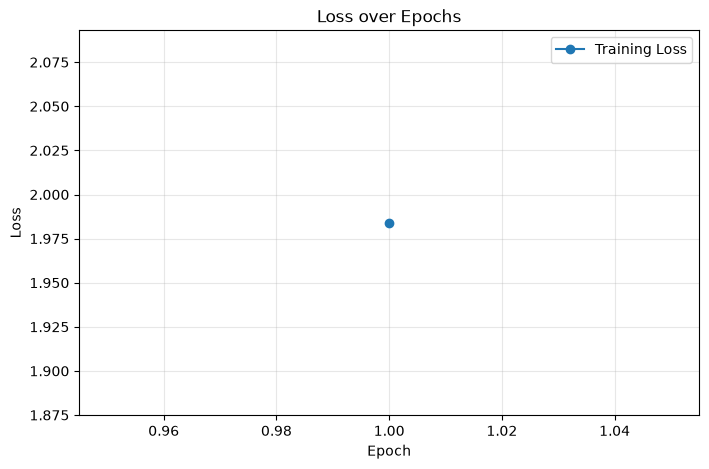

In [46]:
model_dir = os.path.join(os.path.join('model/monai', now))
epochs = 1
train_loss, train_metric, valid_loss, valid_metric, liver_metric, cancer_metric = train(
    model = model,
    train_loader=train_loader,
    test_loader=val_loader,
    loss=loss_function,
    optim=optimizer,
    device = device,
    model_dir=model_dir,
    epochs=epochs,
)

plot_loss(train_loss)

# PREDICT, VISUALIZE

In [11]:
model_dir = './model/monai/2026-08-15-01-44-best_metric_model.pth'

In [12]:
inference_model = Unet(
    spatial_dims=3,
    in_channels=1,
    out_channels=3,
    channels=channels,
    strides=strides,
    num_res_units=2,
    norm=Norm.BATCH  #Norm.INSTANCE
)

inference_model.load_state_dict(torch.load(model_dir, map_location=device))
inference_model = inference_model.to(device)
inference_model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
        

In [20]:
import matplotlib.pyplot as plt

def visualize_prediction(volume, label, prediction, slice_index = None, num_slices = 15):
    """
    volume: tensor/array of shape (C, H, W, D) or (H, W, D)
    label: tensor/array of shape (C, H, W, D) or (H, W, D)
    prediction: tensor/array of shape or (H, W, D) — already argmaxed to class indices
    slice_index: index of slice to display, ranked by foreground content
    num_slices: how many slices to display, applied only if slice index not given, ranked by foreground content (default 5)

    """

    volume = volume.cpu().squeeze().numpy() 
    label = label.cpu().squeeze().numpy()
    prediction = prediction.squeeze().numpy()
    depth = volume.shape[-1]

    if slice_index is None:
        num_slices = min(num_slices, depth)      
        foreground_mask = (label > 0) 
        slice_sums = foreground_mask.sum(axis=(0, 1))
        slice_indices = np.argsort(slice_sums)[::-1][:num_slices]

    else:
        slice_indices = np.array([slice_index])
        num_slices = 1

    print(f"Displaying slices: {list(slice_indices)}")

    fig, axes = plt.subplots(num_slices, 3, figsize=(15, 5 * num_slices), squeeze=False)

    for i, slice_idx in enumerate(slice_indices):
        axes[i, 0].imshow(volume[:, :, slice_idx], cmap='gray')
        axes[i, 0].set_title(f'Input (slice {slice_idx})')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(volume[:, :, slice_idx], cmap='gray')
        axes[i, 1].imshow(label[:, :, slice_idx], cmap='jet', alpha=0.5, vmin=0, vmax=2)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(volume[:, :, slice_idx], cmap='gray')
        axes[i, 2].imshow(prediction[:, :, slice_idx], cmap='jet', alpha=0.5, vmin=0, vmax=2)
        axes[i, 2].set_title('Model Prediction')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


# VISUALIZE FULL VOLUME

In [34]:
sample = inference_transforms({"vol": "./sample/imagesVal/liver_130.nii.gz",
                                "seg": "./sample/labelsVal/liver_130.nii.gz"})

inference_volume = sample['vol'].unsqueeze(0)  # add batch dim: (1, 1, H, W, D) — H,W,D now native size
inference_label = sample['seg'].unsqueeze(0)

print(inference_volume.shape, inference_label.shape)  

torch.Size([1, 1, 234, 181, 437]) torch.Size([1, 1, 234, 181, 437])


In [35]:
from monai.inferers import sliding_window_inference

def compute_full_volume_prediction(inference_volume, spatial_size, inference_model, device):
    inference_model.eval()
    with torch.no_grad():
        output = sliding_window_inference(
            inputs=inference_volume.to(device),
            roi_size=spatial_size,
            sw_batch_size=4,
            predictor=inference_model,
            overlap=0.1,
        )
        prediction = torch.argmax(output, dim=1)
        return prediction.cpu()

prediction = compute_full_volume_prediction(inference_volume, spatial_size, inference_model, device)   
print(prediction.shape, torch.unique(prediction[0]))

torch.Size([1, 234, 181, 437]) metatensor([0, 1, 2])


Displaying slices: [np.int64(351), np.int64(357), np.int64(350), np.int64(356), np.int64(359), np.int64(348), np.int64(360), np.int64(349), np.int64(353), np.int64(358), np.int64(361), np.int64(354), np.int64(352), np.int64(364), np.int64(355)]


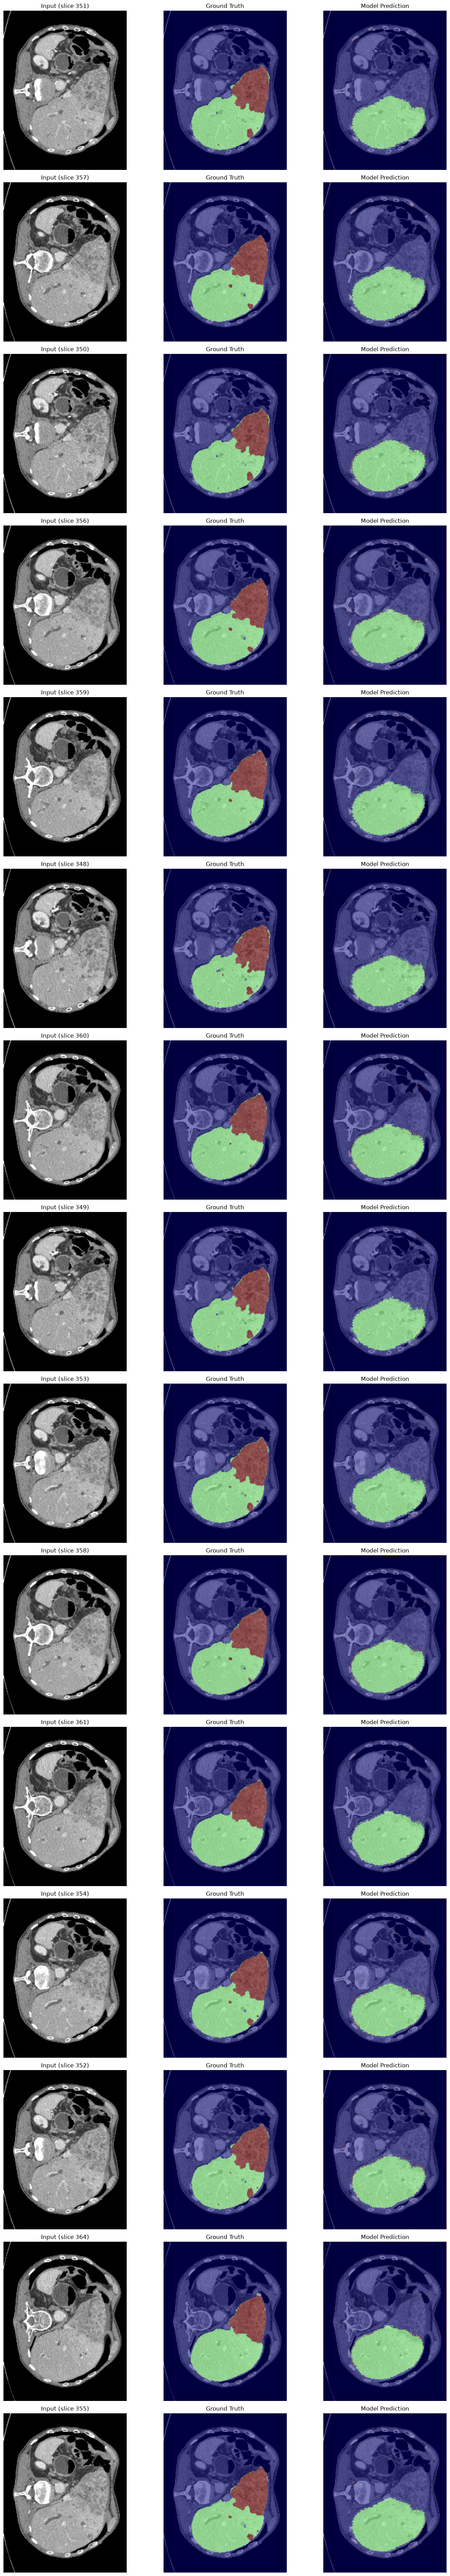

In [23]:
visualize_prediction(inference_volume, inference_label, prediction)
# visualize_prediction(inference_volume, inference_label, prediction, slice_index=351)

In [13]:
valid_inf_loss, valid_inf_metric, liver_inf_metric, cancer_inf_metric = validate(inference_model, val_loader, loss_function, device, roi_size=spatial_size, inference=True)

Validation mode: constant
Dice metric(validation) for liver: 0.7896, cancer: 0.0014


In [15]:
valid_inf_metric, liver_inf_metric, cancer_inf_metric

(0.5078642964363098, 0.7895995378494263, 0.0014087867457419634)

# MISC

In [25]:
sample = valid_transforms(val_files[1])
print(sample['vol'].shape)

torch.Size([1, 245, 232, 474])


In [26]:
%whos list

Variable         Type    Data/Info
----------------------------------
training_files   list    n=50
val_files        list    n=15


In [27]:
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    print("All ok")

All ok


In [28]:
from glob import glob
import json
images = sorted(glob('./sample/imagesVal/*'))
labels = sorted(glob('./sample/labelsVal/*'))
train_img = []
for image, label in zip(images, labels):
    node = {
        'vol': f"./{os.path.relpath(image, os.path.join( os.getcwd(), 'sample'))}",
        'seg': f"./{os.path.relpath(label, os.path.join( os.getcwd(), 'sample'))}",
    }

    train_img.append(node)

print(json.dumps(train_img, indent=2))

print(len(train_img))

[
  {
    "vol": "./imagesVal/liver_101.nii.gz",
    "seg": "./labelsVal/liver_101.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_102.nii.gz",
    "seg": "./labelsVal/liver_102.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_103.nii.gz",
    "seg": "./labelsVal/liver_103.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_104.nii.gz",
    "seg": "./labelsVal/liver_104.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_105.nii.gz",
    "seg": "./labelsVal/liver_105.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_106.nii.gz",
    "seg": "./labelsVal/liver_106.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_107.nii.gz",
    "seg": "./labelsVal/liver_107.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_108.nii.gz",
    "seg": "./labelsVal/liver_108.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_109.nii.gz",
    "seg": "./labelsVal/liver_109.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_110.nii.gz",
    "seg": "./labelsVal/liver_110.nii.gz"
  },
  {
    "vol": "./imagesVal/liver_111.nii.gz",
    "seg": 

In [29]:
images = sorted(glob('./sample/imagesTr/*'))
labels = sorted(glob('./sample/labelsTr/*'))
train_img = []
for image, label in zip(images, labels):
    node = {
        'vol': f"./{os.path.relpath(image, os.path.join( os.getcwd(), 'sample'))}",
        'seg': f"./{os.path.relpath(label, os.path.join( os.getcwd(), 'sample'))}",
    }
    train_img.append(node)
print(len(images), len(labels))
print(json.dumps(train_img, indent=2))


101 101
[
  {
    "vol": "./imagesTr/liver_0.nii.gz",
    "seg": "./labelsTr/liver_0.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_1.nii.gz",
    "seg": "./labelsTr/liver_1.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_10.nii.gz",
    "seg": "./labelsTr/liver_10.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_100.nii.gz",
    "seg": "./labelsTr/liver_100.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_11.nii.gz",
    "seg": "./labelsTr/liver_11.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_12.nii.gz",
    "seg": "./labelsTr/liver_12.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_13.nii.gz",
    "seg": "./labelsTr/liver_13.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_14.nii.gz",
    "seg": "./labelsTr/liver_14.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_15.nii.gz",
    "seg": "./labelsTr/liver_15.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_16.nii.gz",
    "seg": "./labelsTr/liver_16.nii.gz"
  },
  {
    "vol": "./imagesTr/liver_17.nii.gz",
    "seg": "./labelsTr/liver_17.nii.gz"
  },
  

In [18]:
import json

with open("./sample/dataset.json", "r") as file:
    data = json.load(file)

print(len(data['train']))
print(len(data['valid']))
print(data['train'])

50
15
[{'vol': './imagesTr/liver_0.nii.gz', 'seg': './labelsTr/liver_0.nii.gz'}, {'vol': './imagesTr/liver_1.nii.gz', 'seg': './labelsTr/liver_1.nii.gz'}, {'vol': './imagesTr/liver_10.nii.gz', 'seg': './labelsTr/liver_10.nii.gz'}, {'vol': './imagesTr/liver_100.nii.gz', 'seg': './labelsTr/liver_100.nii.gz'}, {'vol': './imagesTr/liver_11.nii.gz', 'seg': './labelsTr/liver_11.nii.gz'}, {'vol': './imagesTr/liver_12.nii.gz', 'seg': './labelsTr/liver_12.nii.gz'}, {'vol': './imagesTr/liver_13.nii.gz', 'seg': './labelsTr/liver_13.nii.gz'}, {'vol': './imagesTr/liver_14.nii.gz', 'seg': './labelsTr/liver_14.nii.gz'}, {'vol': './imagesTr/liver_15.nii.gz', 'seg': './labelsTr/liver_15.nii.gz'}, {'vol': './imagesTr/liver_16.nii.gz', 'seg': './labelsTr/liver_16.nii.gz'}, {'vol': './imagesTr/liver_17.nii.gz', 'seg': './labelsTr/liver_17.nii.gz'}, {'vol': './imagesTr/liver_18.nii.gz', 'seg': './labelsTr/liver_18.nii.gz'}, {'vol': './imagesTr/liver_19.nii.gz', 'seg': './labelsTr/liver_19.nii.gz'}, {'vol':

In [19]:
len(training_files)

50

In [22]:
import numpy as np
import nibabel as nib

total_voxels = 0
liver_voxels = 0
cancer_voxels = 0

for f in training_files:
    label = nib.load(f['seg']).get_fdata()
    total_voxels += label.size
    liver_voxels += np.sum(label == 1)
    cancer_voxels += np.sum(label == 2)

print(f"Total voxels: {total_voxels:.4f}")
print(f"Liver: {liver_voxels / total_voxels:.4%} of all voxels")
print(f"Cancer: {cancer_voxels / total_voxels:.4%} of all voxels")

Total voxels: 4582014976.0000
Liver: 2.3772% of all voxels
Cancer: 0.1224% of all voxels


In [23]:
total_voxels = 0
liver_voxels = 0
cancer_voxels = 0

for batch in train_loader:
    label = batch['seg']
    total_voxels += label.numel()
    liver_voxels += (label == 1).sum().item()
    cancer_voxels += (label == 2).sum().item()


print(f"Total voxels: {total_voxels:.4f}")
print(f"Liver: {liver_voxels / total_voxels:.4%} of all voxels")
print(f"Cancer: {cancer_voxels / total_voxels:.4%} of all voxels")

Total voxels: 209715200.0000
Liver: 18.5129% of all voxels
Cancer: 0.6697% of all voxels
